In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path='house_prices.csv'
df = pd.read_csv(file_path)
df.head()


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [2]:
# =====================================================================
#PROGRAMMATIC MISSING VALUE CHECK
# =====================================================================
print("\n==================================================")
print("            MISSING VALUE ANALYSIS                ")
print("==================================================")
# .isnull() flags empty cells as True, and .sum() counts those Trues per column
missing_counts = df.isnull().sum()
print(missing_counts)

total_missing = missing_counts.sum()
if total_missing == 0:
    print("\n✓ INTEGRITY PASSED: Matrix is 100% complete. No missing entries detected.")
else:
    print(f"\n⚠ WARNING: Found {total_missing} null values. Needs cleaning before modeling.")


            MISSING VALUE ANALYSIS                
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

✓ INTEGRITY PASSED: Matrix is 100% complete. No missing entries detected.


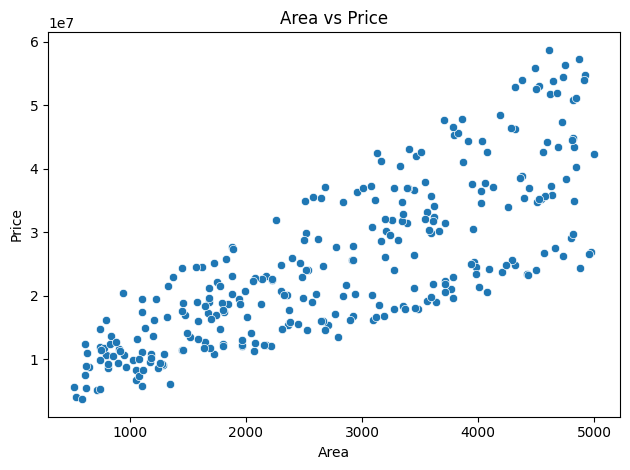

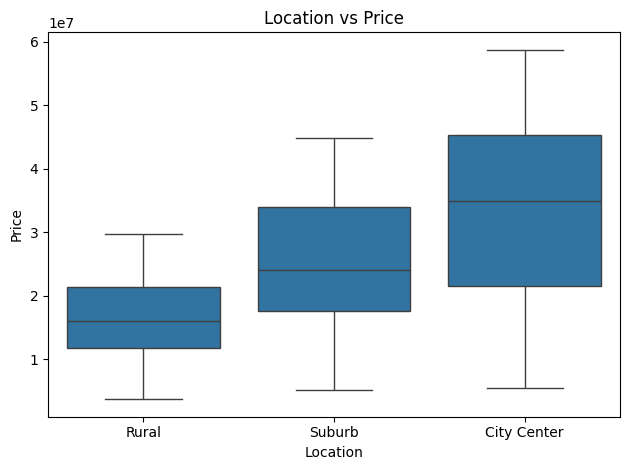

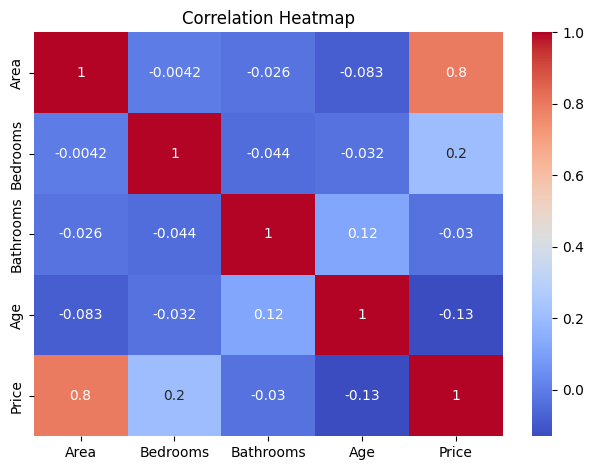

In [4]:
# --- Chart 1: Area vs Price (Scatter Plot) ---
plt.figure()
sns.scatterplot(data=df, x='Area', y='Price')
plt.title('Area vs Price')
plt.tight_layout() 
plt.savefig('area_vs_price.png')
plt.show()

# --- Chart 2: Location vs Price (Boxplot) ---
plt.figure()
sns.boxplot(data=df, x='Location', y='Price')
plt.title('Location vs Price')
plt.tight_layout()
plt.savefig('location_vs_price.png')
plt.show()

# --- Chart 3: All Numeric Relationships (Correlation Heatmap) ---
plt.figure()
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
# Drop the Property_ID column
# We remove this because random tracking IDs do not help the model calculate house prices
df_clean = df.drop(columns=['Property_ID'])

# Convert Categorical Variables (Location & Property_Type) into numbers
df_encoded = pd.get_dummies(df_clean, columns=['Location', 'Property_Type'], drop_first=True)
# Convert True/False formatting to simple integers (1 and 0) so the model can read them
df_encoded = df_encoded.astype({col: 'int64' for col in df_encoded.select_dtypes(include='bool').columns})

print("--- Cleaned & Encoded Data (First 5 Rows) ---")
print(df_encoded.head())


--- Cleaned & Encoded Data (First 5 Rows) ---
   Area  Bedrooms  Bathrooms  Age     Price  Location_Rural  Location_Suburb  \
0  3712         4          3   36  22260000               1                0   
1  1591         4          1   35  16057500               0                1   
2  1646         4          3   20  12730000               1                0   
3  4814         1          2   13  50840000               0                0   
4   800         4          2   38  10650000               0                1   

   Property_Type_House  Property_Type_Villa  
0                    1                    0  
1                    1                    0  
2                    0                    1  
3                    0                    1  
4                    0                    0  


In [6]:
# Separate features (X) from the target price variable (y)
X = df_encoded.drop(columns=['Price'])  # Everything EXCEPT the price column
y = df_encoded['Price']                  # ONLY the price column

# Split the data into Training (80%) and Testing (20%) sets
# random_state=42 locks the shuffle pattern so your results stay consistent every run
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Data Split Summary ---")
print(f"Total rows in dataset: {df_encoded.shape[0]}")
print(f"Training set features (X_train): {X_train.shape[0]} rows")
print(f"Testing set features (X_test):   {X_test.shape[0]} rows")


--- Data Split Summary ---
Total rows in dataset: 300
Training set features (X_train): 240 rows
Testing set features (X_test):   60 rows


In [ ]:
from sklearn.linear_model import LinearRegression
# Drop the non-predictive ID column and convert text to numbers (One-Hot Encoding)
df_clean = df.drop(columns=['Property_ID'])
df_encoded = pd.get_dummies(df_clean, columns=['Location', 'Property_Type'], drop_first=True)
df_encoded = df_encoded.astype({col: 'int64' for col in df_encoded.select_dtypes(include='bool').columns})

# Separate features (X) from the target price (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# =====================================================================
# INITIALIZE AND TRAIN THE MODEL
# =====================================================================
# Create an empty Linear Regression model object
model = LinearRegression()

# Train the model using the training textbook data (X_train and y_train)
# This is where the model calculates the weights/coefficients for each feature
model.fit(X_train, y_train)

print("✓ Model training complete!\n")

# =====================================================================
# GENERATE PREDICTIONS
# =====================================================================
# Use the trained model to predict house prices for the hidden test set
y_pred = model.predict(X_test)

# =====================================================================
# INSPECT THE RESULTS
# =====================================================================
print("--- Looking Inside the Model Parameters ---")
print(f"Base Intercept Price: {model.intercept_:,.2f}")

# Map each feature name to its calculated mathematical weight
for feature, weight in zip(X.columns, model.coef_):
    print(f"Weight for {feature}: {weight:+,.2f}")

print("\n--- First 5 Real vs. Predicted Prices ---")
# Create a quick table comparing what the actual price was vs what our model guessed
comparison_table = pd.DataFrame({
    'Actual Price': y_test.values[:5],
    'Predicted Price': y_pred[:5]
})
print(comparison_table.to_string(index=False, formatters={'Actual Price': '{:,.0f}'.format, 'Predicted Price': '{:,.2f}'.format}))

✓ Model training complete!

--- Looking Inside the Model Parameters ---
Base Intercept Price: 9,180,515.51
Weight for Area: +7,558.96
Weight for Bedrooms: +1,585,708.74
Weight for Bathrooms: +454,594.04
Weight for Age: -82,443.68
Weight for Location_Rural: -16,728,131.05
Weight for Location_Suburb: -8,633,012.01
Weight for Property_Type_House: -607,903.67
Weight for Property_Type_Villa: +63,724.97

--- First 5 Real vs. Predicted Prices ---
Actual Price Predicted Price
   8,930,000   15,074,813.48
  18,085,000   19,163,670.53
  53,980,000   49,321,254.81
  24,800,000   27,009,190.40
  21,615,000   21,543,273.97


In [ ]:

from sklearn.linear_model import LinearRegression
# ---  Get the Prepared Data State ---
df = pd.read_csv('house_prices.csv')
df_clean = df.drop(columns=['Property_ID'])
df_encoded = pd.get_dummies(df_clean, columns=['Location', 'Property_Type'], drop_first=True)
df_encoded = df_encoded.astype({col: 'int64' for col in df_encoded.select_dtypes(include='bool').columns})

X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- FIT THE MODEL (Training Phase) ---
# Initialize the empty Linear Regression model framework
model = LinearRegression()
# "Fit" the model by feeding it the training features and matching target prices
# This calculates the optimal weights (coefficients) under the hood
model.fit(X_train, y_train)
print("✓ Model has successfully fitted its coefficients to the training data.")

# --- MAKE PREDICTIONS (Testing Phase) ---
# Use the fitted model weights to predict values for the unseen test features
y_pred = model.predict(X_test)
print("✓ Predictions successfully generated for the test partition.")
# --- Print Sample Results ---
print("\n--- First 5 Predictions ---")
for i in range(5):
    print(f"Predicted Price: {y_pred[i]:,.2f} | Actual Price: {y_test.values[i]:,d}")

✓ Model has successfully fitted its coefficients to the training data.
✓ Predictions successfully generated for the test partition.

--- First 5 Predictions ---
Predicted Price: 15,074,813.48 | Actual Price: 8,930,000
Predicted Price: 19,163,670.53 | Actual Price: 18,085,000
Predicted Price: 49,321,254.81 | Actual Price: 53,980,000
Predicted Price: 27,009,190.40 | Actual Price: 24,800,000
Predicted Price: 21,543,273.97 | Actual Price: 21,615,000


             MODEL PERFORMANCE METRICS            
Mean Absolute Error (MAE):     2,188,736.34
Mean Squared Error (MSE):      8,454,330,868,276.60
Root Mean Squared Error (RMSE): 2,907,633.21
R-squared (R²) Score:          0.9406 (94.06%)


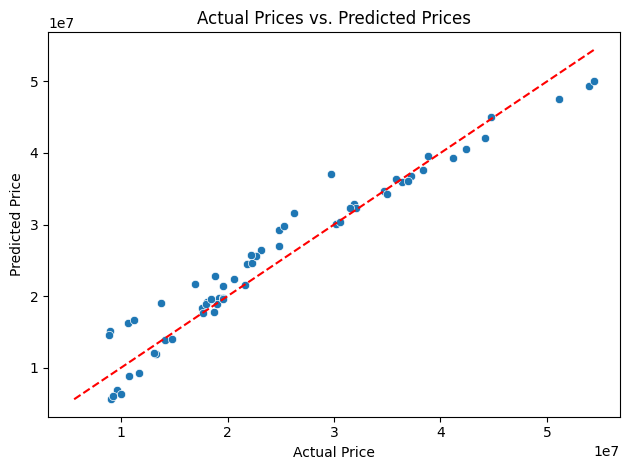


✓ Evaluation complete! Chart successfully saved as 'predictions_vs_actual.png'.


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# squared=False calculates the RMSE directly without needing numpy
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("==================================================")
print("             MODEL PERFORMANCE METRICS            ")
print("==================================================")
print(f"Mean Absolute Error (MAE):     {mae:,.2f}")
print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R²) Score:          {r2:.4f} ({r2*100:.2f}%)")
print("==================================================")

# =====================================================================
# VISUALIZE PREDICTIONS VS ACTUAL VALUES
# =====================================================================
plt.figure()

# Plot the real prices against your model's predictions
sns.scatterplot(x=y_test, y=y_pred)

# Calculate boundaries for the perfect-prediction reference line
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))

# Draw the red diagonal reference line (y = x)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Actual Prices vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()

# Save the visualization to your project folder
plt.savefig('predictions_vs_actual.png')
plt.show()

print("\n✓ Evaluation complete! Chart successfully saved as 'predictions_vs_actual.png'.")

         MODEL ACCURACY COMPARISON (R² Score)     
Polynomial Regression    : 0.9944 (99.44%)
Decision Tree            : 0.8392 (83.92%)
Random Forest            : 0.9711 (97.11%)


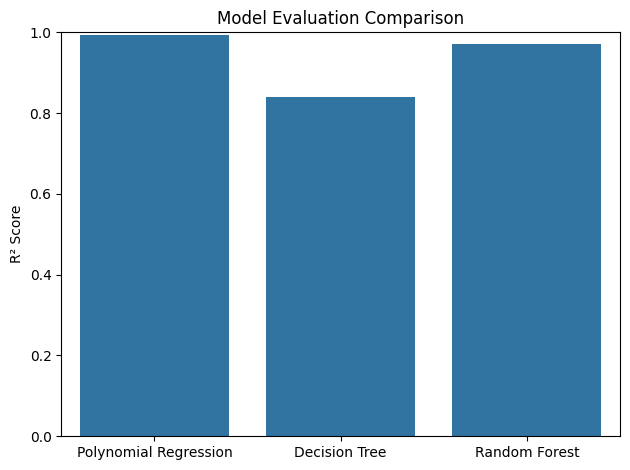

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Dictionary to hold our final model scores for comparison
performance_results = {}

# =====================================================================
# 1. IMPROVEMENT A: POLYNOMIAL FEATURES
# =====================================================================
# Create the polynomial transformer (degree=2 squares the numeric features)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform our features into non-linear combinations
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a linear model on these new curved features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred_poly = poly_model.predict(X_test_poly)
performance_results['Polynomial Regression'] = r2_score(y_test, y_pred_poly)


# =====================================================================
# 2. IMPROVEMENT B: DECISION TREE REGRESSOR
# =====================================================================
# max_depth=4 stops the tree from growing infinitely and overfitting
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
performance_results['Decision Tree'] = r2_score(y_test, y_pred_dt)


# =====================================================================
# 3. IMPROVEMENT C: RANDOM FOREST REGRESSOR
# =====================================================================
# n_estimators=100 means we are building a crowd of 100 trees together
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
performance_results['Random Forest'] = r2_score(y_test, y_pred_rf)


# =====================================================================
# 4. COMPARE AND VISUALIZE MODEL PERFORMANCE
# =====================================================================
print("==================================================")
print("         MODEL ACCURACY COMPARISON (R² Score)     ")
print("==================================================")
for model_name, score in performance_results.items():
    print(f"{model_name:<25}: {score:.4f} ({score*100:.2f}%)")
print("==================================================")

# Generate a clean comparison bar chart
plt.figure()
sns.barplot(x=list(performance_results.keys()), y=list(performance_results.values()))
plt.title('Model Evaluation Comparison')
plt.ylabel('R² Score')
plt.ylim(0, 1.0) # Keeps the scale bounded between 0% and 100%
plt.tight_layout()

# Save comparison chart
plt.savefig('model_comparison_results.png')
plt.show()

          PROJECT INSIGHTS & FEATURE RANKING       
⭐ Area                     : 69.32% impact
⭐ Location_Rural           : 20.17% impact
⭐ Location_Suburb          : 7.36% impact
⭐ Bedrooms                 : 1.91% impact
⭐ Age                      : 0.82% impact
⭐ Bathrooms                : 0.22% impact
⭐ Property_Type_Villa      : 0.11% impact
⭐ Property_Type_House      : 0.08% impact

💡 KEY INSIGHT FOR PRESENTATION:
The model proves that 'Area' is the single largest factor driving
house prices, accounting for 69.3% of the model's predictive power.


C:\Users\GuestUser\AppData\Local\Temp\ipykernel_11020\3699202938.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


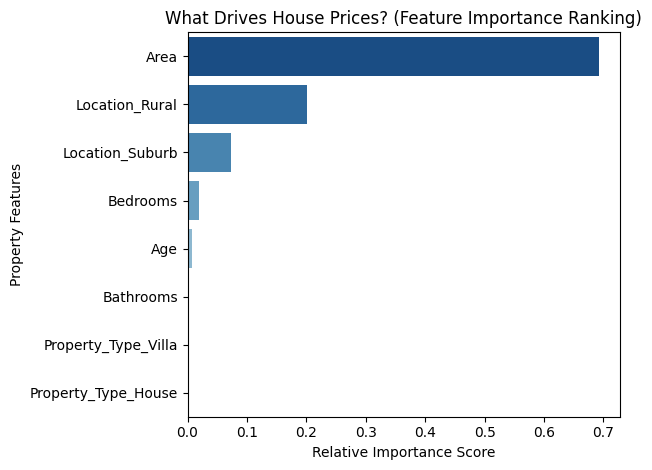


✓ Presentation asset successfully saved as 'final_feature_importance.png'!


In [14]:
# =====================================================================
# 1. EXTRACT FEATURE IMPORTANCE FROM RANDOM FOREST
# =====================================================================
# We pull the raw importance scores from your trained rf_model
importances = rf_model.feature_importances_

# Pair the column names with their matching importance scores
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort features from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# =====================================================================
# 2. PRINT INSIGHTS REPORT
# =====================================================================
print("==================================================")
print("          PROJECT INSIGHTS & FEATURE RANKING       ")
print("==================================================")
for index, row in importance_df.iterrows():
    print(f"⭐ {row['Feature']:<25}: {row['Importance']*100:.2f}% impact")
print("==================================================")

# Identify the top driver automatically
top_feature = importance_df.iloc[0]['Feature']
top_value = importance_df.iloc[0]['Importance'] * 100

print(f"\n💡 KEY INSIGHT FOR PRESENTATION:")
print(f"The model proves that '{top_feature}' is the single largest factor driving")
print(f"house prices, accounting for {top_value:.1f}% of the model's predictive power.")

# =====================================================================
# 3. VISUALIZE AND SAVE THE PRESENTATION CHART
# =====================================================================
plt.figure()

# Create a clean horizontal bar chart for easy reading
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='Blues_r' # Beautiful dark-to-light blue gradient
)

plt.title('What Drives House Prices? (Feature Importance Ranking)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Property Features')
plt.tight_layout()

# Save image asset for your final documentation/presentation slide
plt.savefig('final_feature_importance.png')
plt.show()

print("\n✓ Presentation asset successfully saved as 'final_feature_importance.png'!")